In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd    
df=pd.read_excel("clean_heart_disease_dataset.xlsx")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,70,1,1,145,197,1,0,121,1,1.0,0,0
1,37,1,3,125,179,0,1,174,0,3.9,0,1
2,63,1,2,179,157,1,1,134,0,3.2,0,1
3,69,0,2,125,291,1,2,189,1,2.0,0,1
4,71,0,2,135,282,1,0,135,0,0.3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
495,47,0,0,99,209,0,2,132,0,2.4,2,1
496,58,0,2,96,277,1,2,182,1,2.4,1,1
497,68,0,0,149,260,0,1,141,0,1.6,0,1
498,52,1,0,164,151,1,1,144,1,1.8,1,0


In [15]:
df.shape

(500, 12)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             500 non-null    int64  
 1   Sex             500 non-null    int64  
 2   ChestPainType   500 non-null    int64  
 3   RestingBP       500 non-null    int64  
 4   Cholesterol     500 non-null    int64  
 5   FastingBS       500 non-null    int64  
 6   RestingECG      500 non-null    int64  
 7   MaxHR           500 non-null    int64  
 8   ExerciseAngina  500 non-null    int64  
 9   Oldpeak         500 non-null    float64
 10  ST_Slope        500 non-null    int64  
 11  HeartDisease    500 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 47.0 KB


In [17]:
df.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,53.384000,0.496000,1.484000,136.198000,235.002000,0.458000,0.968000,143.422000,0.512000,2.948600,1.032000,0.724000
std,14.130672,0.500485,1.115452,26.824128,49.365493,0.498732,0.815049,32.566687,0.500357,1.770765,0.819952,0.447464
min,29.000000,0.000000,0.000000,90.000000,150.000000,0.000000,0.000000,90.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,0.000000,0.750000,113.000000,192.000000,0.000000,0.000000,114.750000,0.000000,1.300000,0.000000,0.000000
50%,53.000000,0.000000,1.000000,136.000000,237.000000,0.000000,1.000000,141.500000,1.000000,3.000000,1.000000,1.000000
75%,66.000000,1.000000,2.000000,160.000000,277.250000,1.000000,2.000000,173.000000,1.000000,4.500000,2.000000,1.000000
max,77.000000,1.000000,3.000000,180.000000,320.000000,1.000000,2.000000,200.000000,1.000000,6.000000,2.000000,1.000000


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [3]:
df.HeartDisease

0      0
1      1
2      1
3      1
4      1
      ..
495    1
496    1
497    1
498    0
499    1
Name: HeartDisease, Length: 500, dtype: int64

In [4]:
df["HeartDisease"].value_counts()

HeartDisease
1    362
0    138
Name: count, dtype: int64

In [5]:
df0 = df[df["HeartDisease"]==0]
df1 = df[df["HeartDisease"]==1]

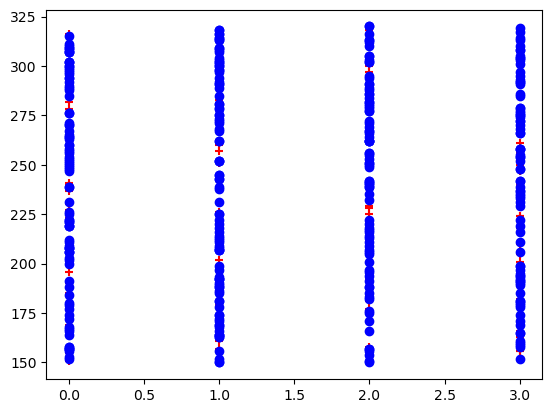

In [6]:
plt.scatter(df0["ChestPainType"],df0["Cholesterol"],marker = "+",color = "red")
plt.scatter(df1["ChestPainType"],df1["Cholesterol"],marker = "o",color = "b")
plt.show()

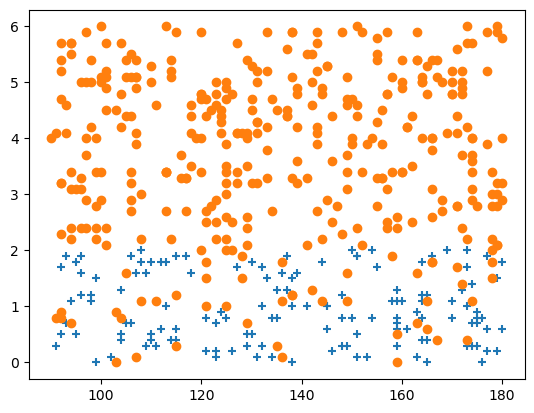

In [7]:
plt.scatter(df0["RestingBP"],df0["Oldpeak"],marker = "+")
plt.scatter(df1["RestingBP"],df1["Oldpeak"],marker = "o")
plt.show()

In [8]:
x=df.drop(columns="HeartDisease")
y=df["HeartDisease"]

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [11]:
sm=SVC()

In [12]:
sm.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [13]:
print("Train accuracy",sm.score(x_train,y_train))
print("Test accuracy",sm.score(x_test,y_test))

Train accuracy 0.7175
Test accuracy 0.75


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = sm.predict(x_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 0 25]
 [ 0 75]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        25
           1       0.75      1.00      0.86        75

    accuracy                           0.75       100
   macro avg       0.38      0.50      0.43       100
weighted avg       0.56      0.75      0.64       100

